# Created by: Prateek Kumar 

## 1. Playing Around with Data

In [1]:
#Importing all the libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn import preprocessing
from pca import pca


In [2]:
#1.a Load the data set

df = pd.read_csv('../assignment_1.csv',parse_dates=['date'])
df.head()

,date,nominal_effective_exchange_rate,effective_federal_funds_rate,cpi_index,djia_adj_close,gold_price
0,1985-02-01,171.491304,8.35,105.3,1286.770020,299.1
1,1985-03-01,176.187000,8.50,105.8,1284.010010,303.9
2,1985-05-01,170.949545,8.27,106.5,1258.060059,316.4
3,1985-06-01,171.393913,7.97,107.3,1315.410034,316.5
4,1985-08-01,164.653478,7.88,108.3,1347.449951,329.8


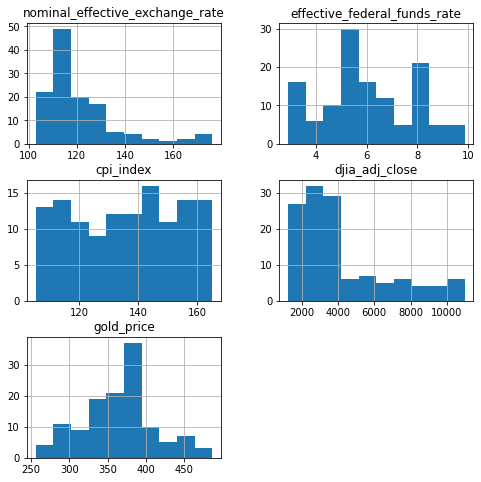

In [3]:
#1.b. Create histograms of the features in a single figure containing only data from before the year 2000

df.set_index('date',inplace=True)

hist = df[:'1999-12-31'].hist(figsize=(8,8))

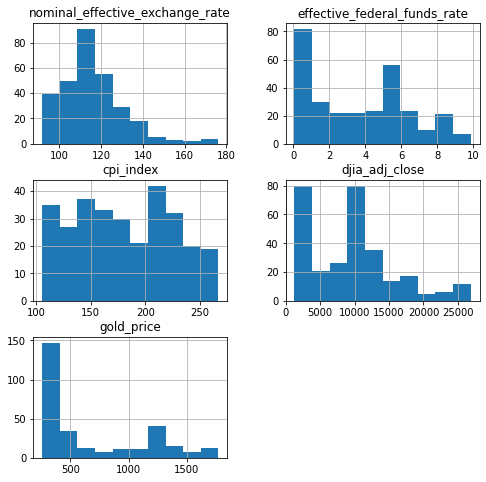

In [4]:
#1.c. Create similar histograms for the full data set and from data after the year 2010

#full data set
hist = df.hist(figsize=(8,8))

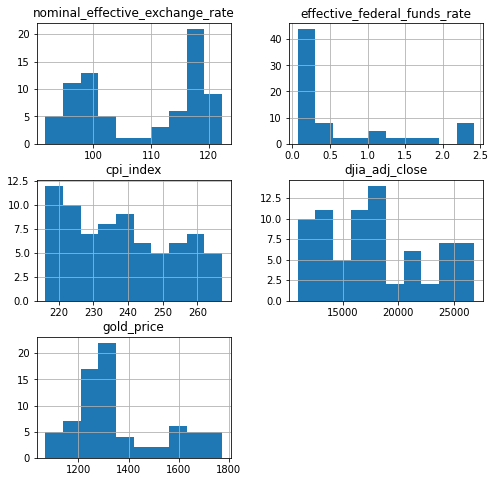

In [5]:
#1.c. Create similar histograms for the full data set and from data after the year 2010

#after the year 2010
hist = df['2011-01-01':].hist(figsize=(8,8))

array([<AxesSubplot:xlabel='date'>, <AxesSubplot:xlabel='date'>,
       <AxesSubplot:xlabel='date'>, <AxesSubplot:xlabel='date'>,
       <AxesSubplot:xlabel='date'>], dtype=object)

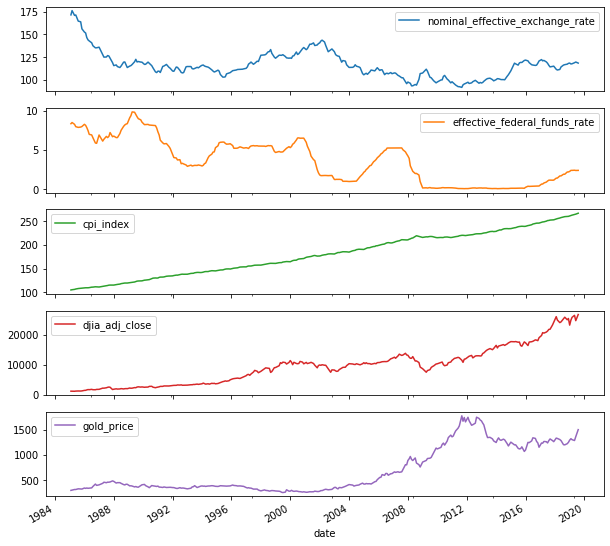

In [7]:
#1.e Create line charts of the features with the date as x axis.

df.plot(figsize=(10,10),subplots=True)

## 2. Feature Correlation

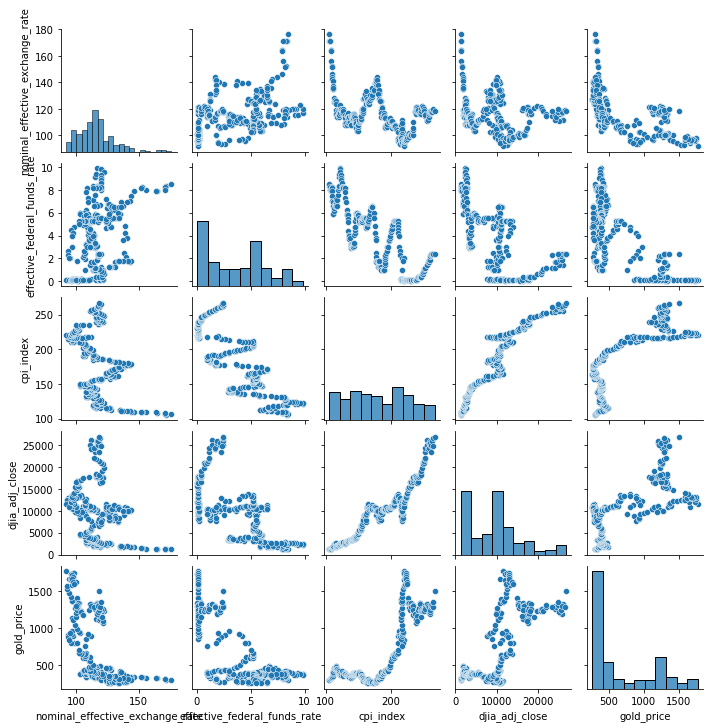

In [9]:
#2.a Create a scatter plot matrix (i.e., pairwise scatter plots of all feature pairs arranged in a matrix) of all features

sns.pairplot(df, height=2.0)

In [10]:
#2.b. Which features do you expect to be highly correlated? Do the scatter plots confirm your assumptions?

#Ans: 'djia_adj_close' & 'cpi_index' and 'cpi_index' & 'gold_price' are correlated as the data moves uphill showing positive correlation.

In [11]:
#2.c Next, compute the correlation matrix using pearson correlation

df_corr = df.corr(method='pearson')
round(df_corr,2)

,nominal_effective_exchange_rate,effective_federal_funds_rate,cpi_index,djia_adj_close,gold_price
nominal_effective_exchange_rate,1.00,0.46,-0.46,-0.27,-0.54
effective_federal_funds_rate,0.46,1.00,-0.82,-0.66,-0.72
cpi_index,-0.46,-0.82,1.00,0.94,0.81
djia_adj_close,-0.27,-0.66,0.94,1.00,0.71
gold_price,-0.54,-0.72,0.81,0.71,1.00


<AxesSubplot:>

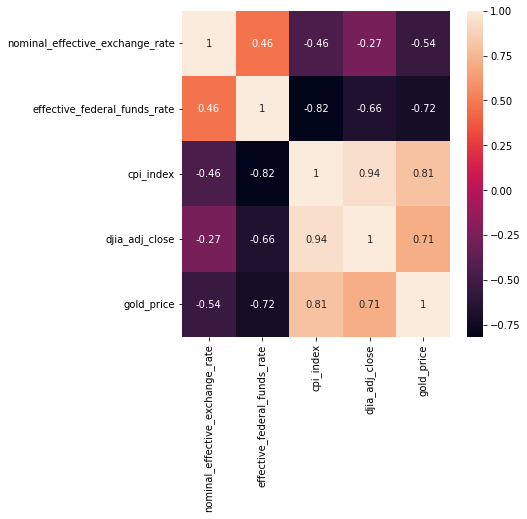

In [12]:
#2.d Use matplotlib or seaborn to visualize the correlation matrix so it is easier to see which features are highly correlated.

plt.figure(figsize=(6,6)) 
sns.heatmap(df.corr(),annot=True)

In [13]:
#2.e What are the highest correlated features? Are any features strongly correlated with the “gold_price”?

#Ans: Highest Correlated features are:
#       1. 'djia_adj_close' & 'cpi_index' 
#       2. 'cpi_index' & 'gold_price'

#     Highly negatively correlated values are 'effective_federal_funds_rate' and 'cpi_index'

#     'cpi_index' is strongly correlated with the 'gold_price'

## 3. Principal Component Analysis

In [14]:
#3.a Compute the principle components of the data using sklearn.decomposition.PCA

pca = PCA()
pca.fit(df)
#'components_' is eigen vectors.
print(abs(pca.components_))
#'explained_variance_' is eigen values
print(pca.explained_variance_)



[[6.34618192e-04 2.96819744e-04 6.78341977e-03 9.98656898e-01
  5.13604429e-02]
 [2.31721823e-02 3.06298368e-03 2.76489537e-02 5.15308684e-02
  9.98014916e-01]
 [6.51853606e-01 6.59512673e-02 7.54583587e-01 3.68566820e-03
  3.64325723e-02]
 [7.57606291e-01 8.84941104e-02 6.46672778e-01 3.89638385e-03
  7.97858455e-04]
 [2.41294821e-02 9.93886187e-01 1.07737867e-01 4.52062461e-04
  6.02451384e-04]]
[3.92778136e+07 9.90895862e+04 2.30680569e+02 8.21945743e+01
 1.79209737e+00]


In [15]:
#3.b. Look at the first component. Which feature has the most contribution? Why do you think this is the case?

#Ans. From the first component, 'djia_adj_close' seem to be the contributing the most because it has the highest value of 9.98.

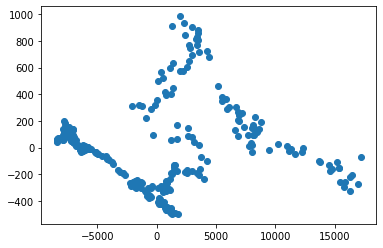

In [16]:
#3.c Create a scatter plot of the transformed data using the first two components. (Optional: Use the color of points to indicate the date, e.g., bright for earliest and dark for latest)from sklearn import datasets

x_pca = pca.transform(df)
plt.scatter(x_pca[:,0],x_pca[:,1])

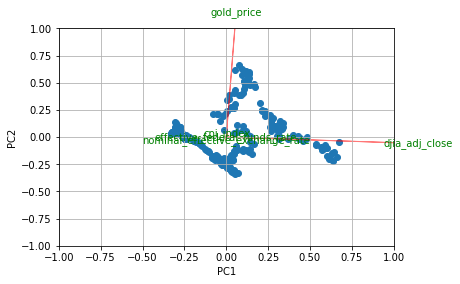

In [17]:
#3.d Now create a biplot of the first two components
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df)
X=scaler.transform(df)    
pca = PCA()
x_new = pca.fit_transform(df)

def myplot(score,coeff,labels=['nominal_effective_exchange_rate','effective_federal_funds_rate','cpi_index','djia_adj_close','gold_price']):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    plt.grid()

myplot(x_new[:,0:2],np.transpose(pca.components_[0:2, :]))
plt.show()

In [18]:
#3.e Are the axes of the transformed data dominated by certain features? Why could this be or why is it not happening?

#Ans: Yes the axes are dominated by 'djia_adj_close' and 'gold_price'. This might be because of the high range in the values of these two features.

In [19]:
#3.f. Normalize the original data. Which method makes the most sense for each feature?

d = preprocessing.normalize(df)
scaled_df = pd.DataFrame(d)
scaled_df

,0,1,2,3,4
0,0.128329,0.006248,0.078797,0.962906,0.223820
1,0.131934,0.006365,0.079226,0.961503,0.227569
2,0.130217,0.006299,0.081124,0.958299,0.241011
3,0.125288,0.005826,0.078436,0.961556,0.231359
4,0.117511,0.005624,0.077292,0.961657,0.235374
...,...,...,...,...,...
291,0.004691,0.000096,0.010476,0.998543,0.052728
292,0.004535,0.000092,0.010137,0.998681,0.050131
293,0.004463,0.000091,0.009932,0.998777,0.048225
294,0.004812,0.000096,0.010668,0.998435,0.054679


In [20]:
#3.g. Now perform the PCA analysis again on the normalized data. Are the results different?

pca = PCA()
pca.fit(scaled_df)
#'components_' is eigen vectors.
print(pca.components_)
#'explained_variance_' is eigen values
print(pca.explained_variance_)

# Yes the results are different and the principle componets (based on the highest values) are 'gold_price' and 'nominal_effective_exchange_rate'

[[ 3.37139391e-01  1.96844887e-02  2.40550608e-01 -1.35143144e-01
   8.99900710e-01]
 [ 7.90944086e-01  4.19906235e-02  4.32190319e-01 -7.65410197e-02
  -4.24260816e-01]
 [ 4.21965229e-01 -6.48770663e-04 -8.28940481e-01 -3.67058915e-01
   8.38793739e-03]
 [-2.86047666e-01  3.56159258e-02  2.59104212e-01 -9.16338234e-01
  -1.00486254e-01]
 [-2.94374160e-02  9.98288732e-01 -3.27050524e-02  3.83379328e-02
   3.69156093e-03]]
[3.68911079e-03 2.30026767e-04 1.59616491e-05 1.20429379e-06
 1.51168611e-07]


## 4. Missing Values

In [21]:
#4.a. Load the data in “assignment_2.csv”. This is the same data as before, however,cosmic rayscale compromised some entries :)

df2 = pd.read_csv('/home/prateek/Prateek/Courses/DataScience/Assignments/2/assignment_2.csv',parse_dates=['date'])

In [22]:
#4.b. Which features have missing values?

df2.isnull().any()

date                               False
nominal_effective_exchange_rate     True
effective_federal_funds_rate        True
cpi_index                           True
djia_adj_close                      True
gold_price                         False
dtype: bool

In [23]:
#4.b. How many missing values are there?

df2.isnull().sum()

date                                0
nominal_effective_exchange_rate    94
effective_federal_funds_rate       92
cpi_index                          81
djia_adj_close                     91
gold_price                          0
dtype: int64

In [24]:
#4.c. Fill in the missing values using the mean value of each feature. Does this approach make sense for every feature? What would be an alternative method that would be more suited for the features?

df3 = df2.fillna(df.mean())

#Ans: If the variable follows a normal distribution, the mean and median are approximately the same. If the variable has a skewed distribution, then the median is a better representation.

In [25]:
#4.d. Compare the distribution of the features of the original data (“assignment_1.csv”) with their distribution of this new data with filled in missing values.

#Assignmet 1 CSV Data

df.describe()


,nominal_effective_exchange_rate,effective_federal_funds_rate,cpi_index,djia_adj_close,gold_price
count,296.000000,296.000000,296.000000,296.000000,296.000000
mean,115.890172,3.621047,180.961818,9664.794209,686.019257
std,14.636330,2.794171,45.264254,6258.804946,449.786208
min,91.683043,0.070000,105.300000,1258.060059,256.100000
25%,106.889269,0.995000,142.300000,3633.209961,352.175000
50%,114.592826,3.560000,179.600000,10018.145020,408.850000
75%,121.318556,5.560000,218.074500,12582.765137,1163.550000
max,176.187000,9.850000,267.101000,26864.269531,1771.900000


In [26]:
#Assignmet 2 CSV Data

df3.describe()

,nominal_effective_exchange_rate,effective_federal_funds_rate,cpi_index,djia_adj_close,gold_price
count,296.000000,296.000000,296.000000,296.000000,296.000000
mean,116.031566,3.635190,179.366420,9938.536988,686.019257
std,11.634677,2.304466,39.258116,5448.429195,449.786208
min,93.366667,0.070000,105.300000,1258.060059,256.100000
25%,110.910109,1.982500,150.375000,7891.879883,352.175000
50%,115.890172,3.621047,180.961818,9664.794209,408.850000
75%,117.723864,5.250000,204.889250,10976.452393,1163.550000
max,171.393913,9.850000,265.137000,26592.910156,1771.900000


array([<AxesSubplot:title={'center':'gold_price'}>], dtype=object)

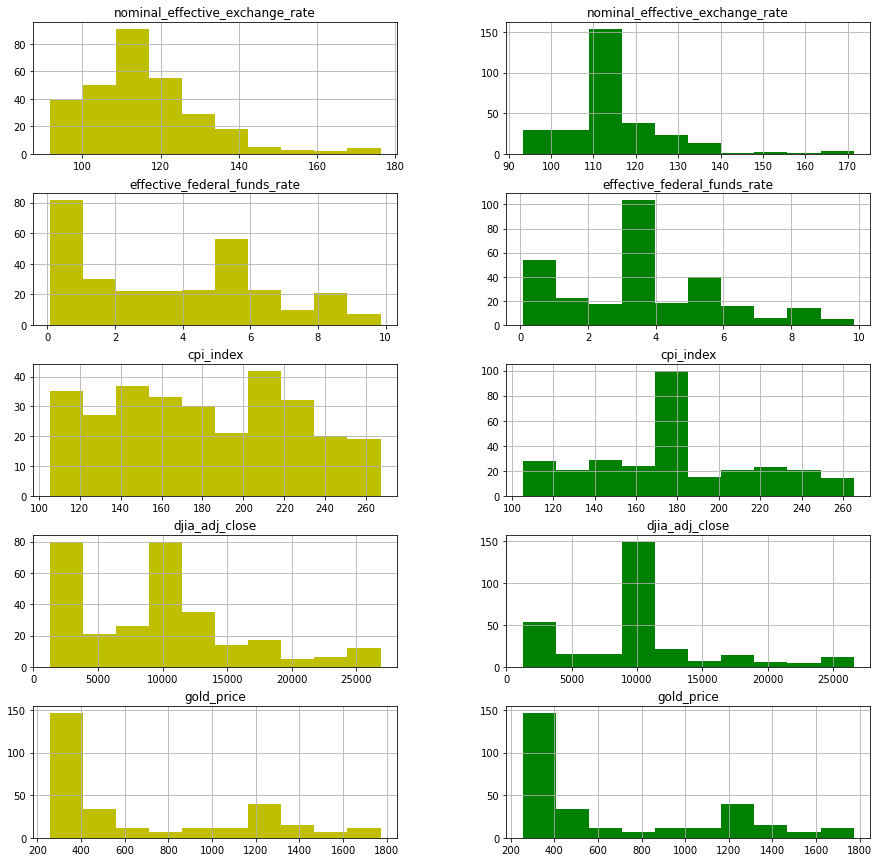

In [27]:
fig, axes = plt.subplots(5, 2,figsize=(15,15))

df.hist('nominal_effective_exchange_rate', ax=axes[0,0], color='y')
df3.hist('nominal_effective_exchange_rate',ax=axes[0,1], color='g')

df.hist('effective_federal_funds_rate', ax=axes[1,0],color='y')
df3.hist('effective_federal_funds_rate',ax=axes[1,1], color='g')

df.hist('cpi_index', ax=axes[2,0],color='y')
df3.hist('cpi_index',ax=axes[2,1], color='g')

df.hist('djia_adj_close', ax=axes[3,0],color='y')
df3.hist('djia_adj_close',ax=axes[3,1],color='g')

df.hist('gold_price', ax=axes[4,0],color='y')
df3.hist('gold_price',ax=axes[4,1],color='g')

# Yellow defines data from Assignment 1 and Green defines data from Assignment 2

In [28]:
# We observe that mean changes/increases in the new data.